# 🌍 Customer Intelligence System
### End-to-End ML Pipeline: Classification | Ensemble Learning | Clustering

**Dataset:** Country Socioeconomic Indicators  
**Models:** Random Forest · XGBoost · K-Means · DBSCAN  
**Goal:** Predict development class & uncover actionable country segments


## 1. Imports & Configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Styling
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
print("✅ Libraries loaded successfully")


ModuleNotFoundError: No module named 'xgboost'

## 2. Data Loading & Initial Exploration

In [ ]:
df = pd.read_csv('Country-data.csv')
print(f"Shape: {df.shape}")
df.head(10)


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [ ]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe().round(2)


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB

=== Statistical Summary ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")


=== Missing Values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing: 0

Duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

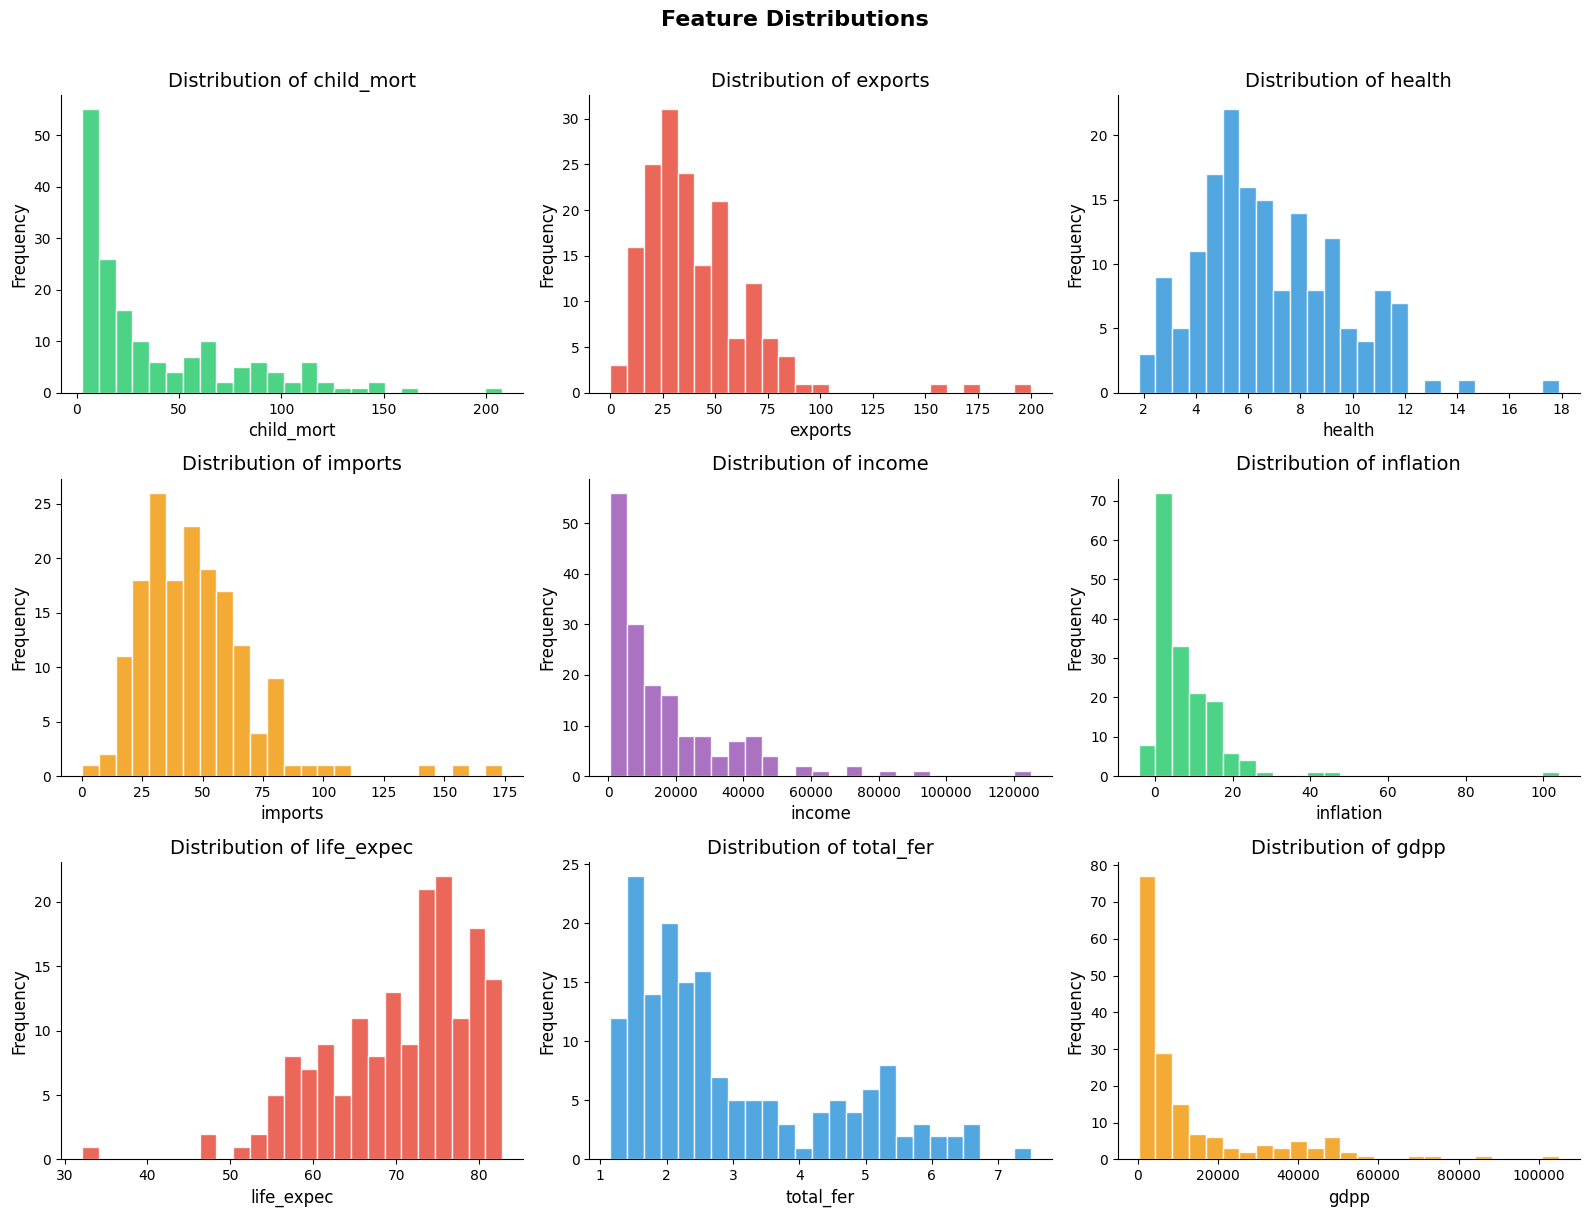

In [ ]:
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=120, bbox_inches='tight')
plt.show()


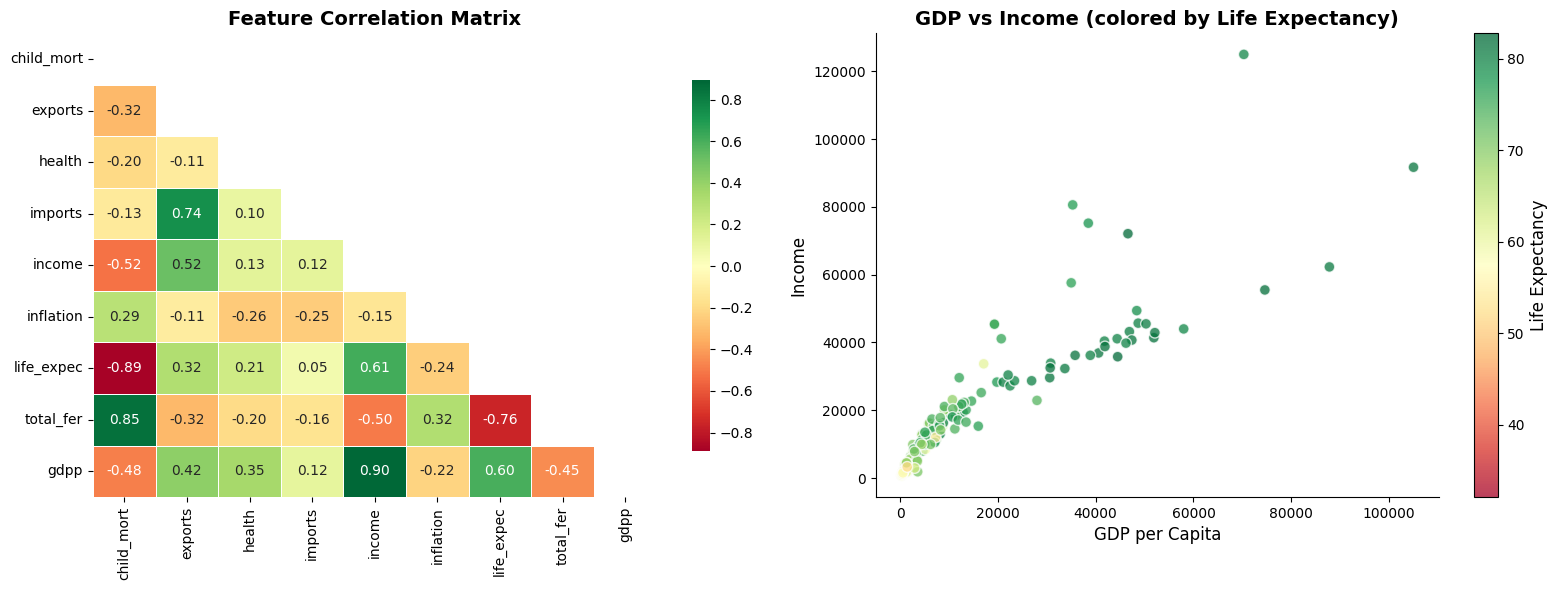

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# GDP vs Income scatter
scatter = axes[1].scatter(df['gdpp'], df['income'], c=df['life_expec'],
                          cmap='RdYlGn', alpha=0.75, s=60, edgecolor='white')
plt.colorbar(scatter, ax=axes[1], label='Life Expectancy')
axes[1].set_xlabel('GDP per Capita')
axes[1].set_ylabel('Income')
axes[1].set_title('GDP vs Income (colored by Life Expectancy)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_insights.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Outlier analysis using IQR
print("=== Outlier Count per Feature (IQR method) ===")
for col in features:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col:12s}: {len(outliers):3d} outliers")


=== Outlier Count per Feature (IQR method) ===
  child_mort  :   4 outliers
  exports     :   5 outliers
  health      :   2 outliers
  imports     :   4 outliers
  income      :   8 outliers
  inflation   :   5 outliers
  life_expec  :   3 outliers
  total_fer   :   1 outliers
  gdpp        :  25 outliers


## 4. Feature Engineering & Target Creation

In [ ]:
# Composite development index (weighted score)
df['dev_score'] = (
    0.25 * (df['gdpp']      / df['gdpp'].max()) +
    0.25 * (df['income']    / df['income'].max()) +
    0.20 * (df['life_expec']/ df['life_expec'].max()) +
    0.15 * (1 - df['child_mort'] / df['child_mort'].max()) +
    0.10 * (df['health']    / df['health'].max()) +
    0.05 * (1 - df['inflation'].clip(lower=0) / df['inflation'].clip(lower=0).max())
)

# Three-class target
bins = [0, 0.33, 0.66, 1.01]
labels = ['Underdeveloped', 'Developing', 'Developed']
df['dev_class'] = pd.cut(df['dev_score'], bins=bins, labels=labels)

print("Class distribution:")
print(df['dev_class'].value_counts())
print(f"\nDev-score range: {df['dev_score'].min():.3f} – {df['dev_score'].max():.3f}")

# Additional engineered features
df['trade_balance'] = df['exports'] - df['imports']
df['health_gdp_ratio'] = df['health'] / (df['gdpp'] + 1)

df.head(3)


Class distribution:
dev_class
Developing        128
Underdeveloped     31
Developed           8
Name: count, dtype: int64

Dev-score range: 0.168 – 0.869


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,dev_score,dev_class,trade_balance,health_gdp_ratio
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0.313045,Underdeveloped,-34.9,0.013682
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0.436360,Developing,-20.6,0.001601
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0.417070,Developing,7.0,0.000935


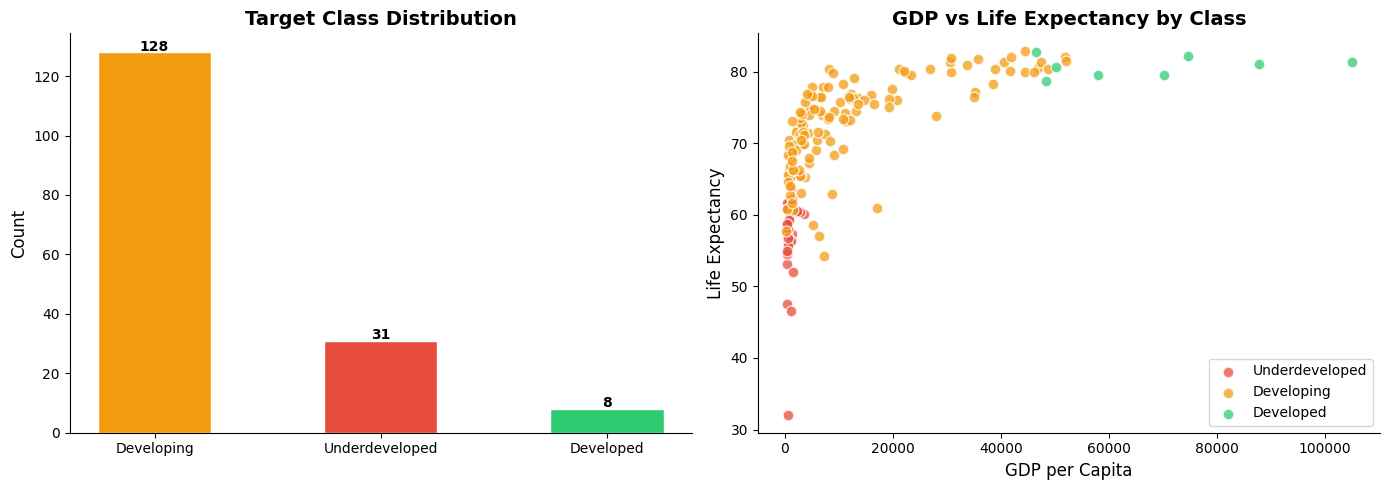

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {'Underdeveloped': '#e74c3c', 'Developing': '#f39c12', 'Developed': '#2ecc71'}
counts = df['dev_class'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors_map[c] for c in counts.index], edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

for cls, color in colors_map.items():
    subset = df[df['dev_class'] == cls]
    axes[1].scatter(subset['gdpp'], subset['life_expec'],
                    label=cls, color=color, alpha=0.75, s=60, edgecolor='white')
axes[1].set_xlabel('GDP per Capita')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('GDP vs Life Expectancy by Class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Preprocessing & Train-Test Split

In [ ]:
feature_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp',
                'trade_balance', 'health_gdp_ratio']

X = df[feature_cols].copy()
le = LabelEncoder()
y = le.fit_transform(df['dev_class'])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Class mapping: {'Developed': np.int64(0), 'Developing': np.int64(1), 'Underdeveloped': np.int64(2)}

Train: (133, 11) | Test: (34, 11)


## 6. Classification Models

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Accuracy   : {cv:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return {'model': model, 'name': name, 'acc': acc, 'cv': cv, 'y_pred': y_pred}

results = {}

# Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
results['Logistic Regression'] = evaluate_model('Logistic Regression', lr, X_train_sc, y_train, X_test_sc, y_test)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
results['Decision Tree'] = evaluate_model('Decision Tree', dt, X_train_sc, y_train, X_test_sc, y_test)



  Logistic Regression
  Test Accuracy : 0.9706
  CV Accuracy   : 0.9405

  Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         2
    Developing       1.00      0.96      0.98        26
Underdeveloped       0.86      1.00      0.92         6

      accuracy                           0.97        34
     macro avg       0.95      0.99      0.97        34
  weighted avg       0.97      0.97      0.97        34


  Decision Tree
  Test Accuracy : 0.9706
  CV Accuracy   : 0.8422

  Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         2
    Developing       1.00      0.96      0.98        26
Underdeveloped       0.86      1.00      0.92         6

      accuracy                           0.97        34
     macro avg       0.95      0.99      0.97        34
  weighted avg       0.97      0.97      0.97        34



## 7. Ensemble Learning — Random Forest & XGBoost

In [ ]:
# Random Forest with hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_sc, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)
results['Random Forest'] = evaluate_model('Random Forest (Tuned)', best_rf, X_train_sc, y_train, X_test_sc, y_test)


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}



  Random Forest (Tuned)
  Test Accuracy : 0.9706
  CV Accuracy   : 0.9028

  Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         2
    Developing       1.00      0.96      0.98        26
Underdeveloped       0.86      1.00      0.92         6

      accuracy                           0.97        34
     macro avg       0.95      0.99      0.97        34
  weighted avg       0.97      0.97      0.97        34



In [ ]:
# XGBoost with hyperparameter tuning
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    xgb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_sc, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)
results['XGBoost'] = evaluate_model('XGBoost (Tuned)', best_xgb, X_train_sc, y_train, X_test_sc, y_test)


Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}



  XGBoost (Tuned)
  Test Accuracy : 0.9706
  CV Accuracy   : 0.9328

  Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         2
    Developing       1.00      0.96      0.98        26
Underdeveloped       0.86      1.00      0.92         6

      accuracy                           0.97        34
     macro avg       0.95      0.99      0.97        34
  weighted avg       0.97      0.97      0.97        34



In [ ]:
# Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('lr',  lr)
    ],
    voting='soft'
)
results['Voting Ensemble'] = evaluate_model('Voting Ensemble', voting_clf, X_train_sc, y_train, X_test_sc, y_test)



  Voting Ensemble
  Test Accuracy : 0.9706
  CV Accuracy   : 0.9179

  Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         2
    Developing       1.00      0.96      0.98        26
Underdeveloped       0.86      1.00      0.92         6

      accuracy                           0.97        34
     macro avg       0.95      0.99      0.97        34
  weighted avg       0.97      0.97      0.97        34



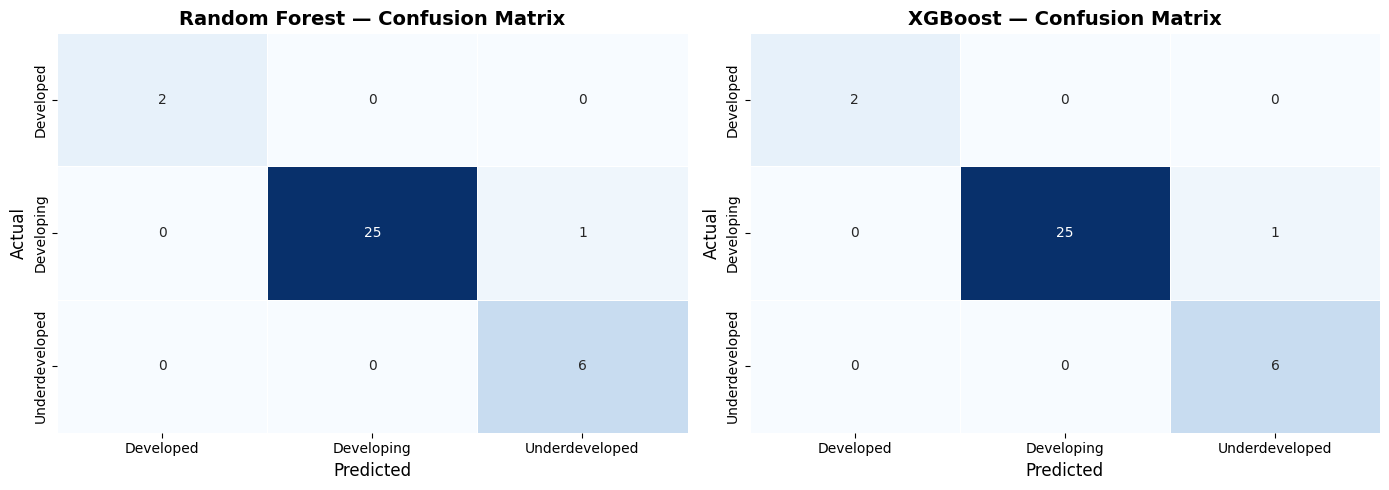

In [ ]:
# Confusion matrices for best models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in zip(axes, ['Random Forest', 'XGBoost'], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, results[key]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, cbar=False)
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


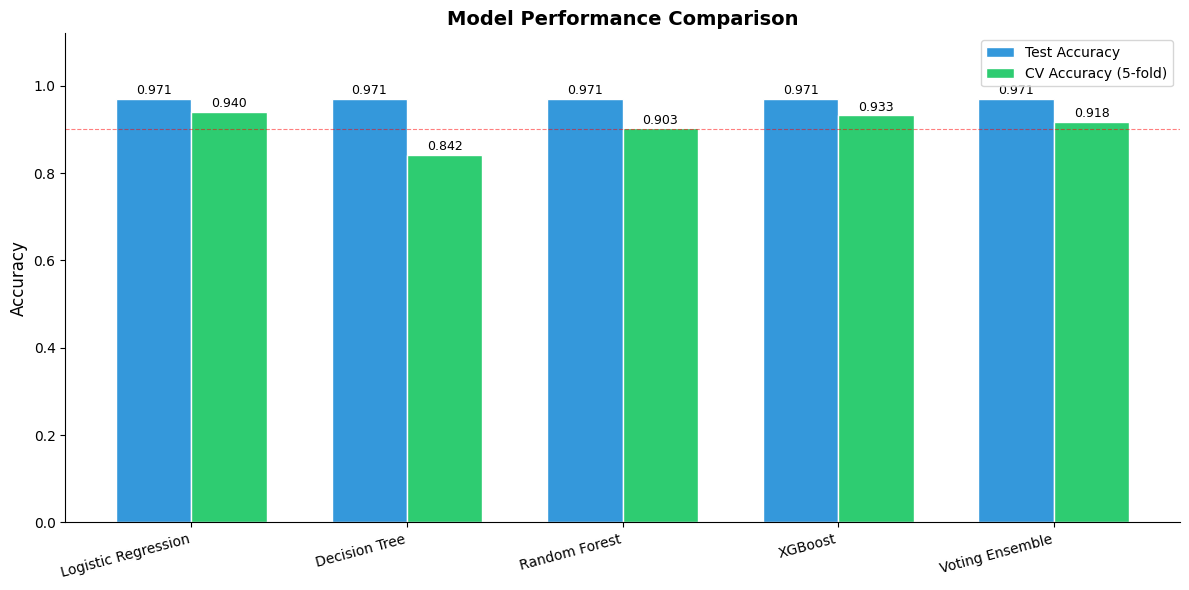

In [ ]:
# Model comparison bar chart
model_names = list(results.keys())
test_accs = [results[m]['acc'] for m in model_names]
cv_accs   = [results[m]['cv']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',  color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, cv_accs,   width, label='CV Accuracy (5-fold)', color='#2ecc71', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('Accuracy'); ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend(); ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


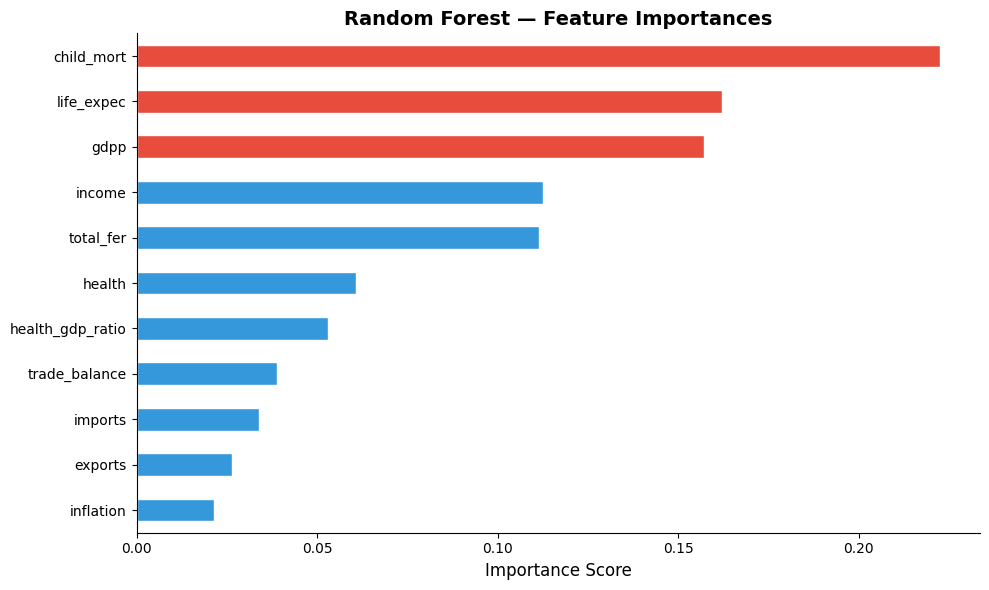

In [ ]:
# Feature Importance (Random Forest)
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i >= len(importances)-3 else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Customer Segmentation — K-Means & DBSCAN

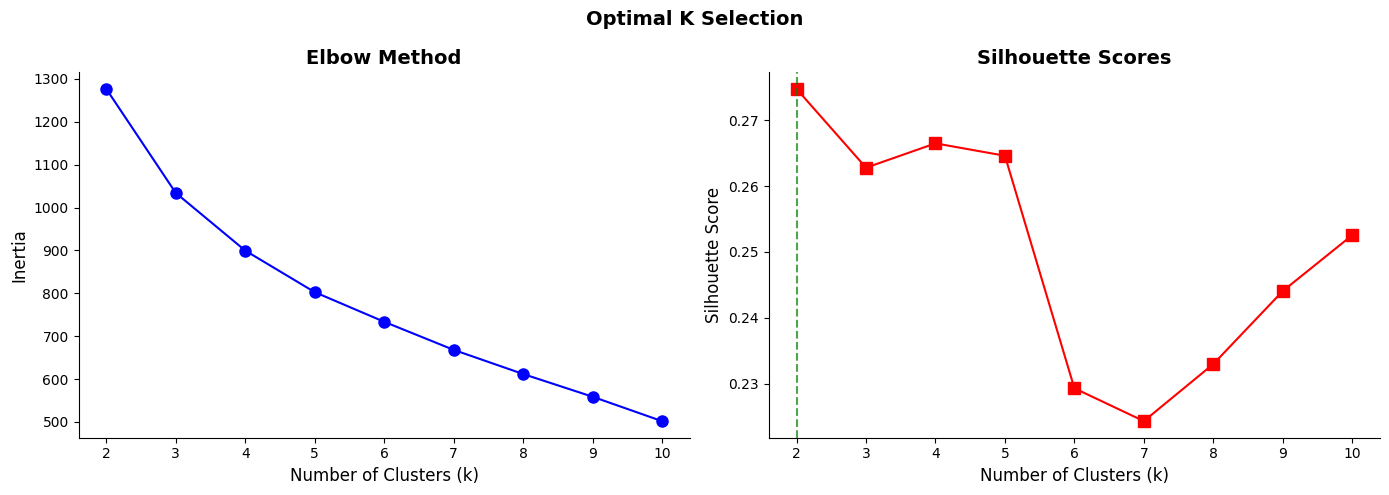


Optimal k by silhouette: 2


In [ ]:
X_cluster = scaler.transform(df[feature_cols])

# Elbow Method + Silhouette
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(k_range, silhouettes, 'rs-', markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].axvline(silhouettes.index(max(silhouettes))+2, color='green', linestyle='--', alpha=0.7)

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=120, bbox_inches='tight')
plt.show()

optimal_k = silhouettes.index(max(silhouettes)) + 2
print(f"\nOptimal k by silhouette: {optimal_k}")


In [ ]:
# Final K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_cluster)

sil_km = silhouette_score(X_cluster, df['kmeans_cluster'])
db_km  = davies_bouldin_score(X_cluster, df['kmeans_cluster'])
ch_km  = calinski_harabasz_score(X_cluster, df['kmeans_cluster'])

print("=== K-Means Metrics ===")
print(f"  Silhouette Score      : {sil_km:.4f}  (higher is better)")
print(f"  Davies-Bouldin Index  : {db_km:.4f}  (lower is better)")
print(f"  Calinski-Harabasz     : {ch_km:.2f}  (higher is better)")
print(f"\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())


=== K-Means Metrics ===
  Silhouette Score      : 0.2748  (higher is better)
  Davies-Bouldin Index  : 1.3799  (lower is better)
  Calinski-Harabasz     : 65.08  (higher is better)

Cluster sizes:
kmeans_cluster
0     67
1    100
Name: count, dtype: int64


In [ ]:
# DBSCAN
best_sil, best_eps, best_min = -1, 0.5, 5
for eps in [0.5, 1.0, 1.5, 2.0]:
    for ms in [3, 5, 10]:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        lbs = dbs.fit_predict(X_cluster)
        n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
        if n_clusters >= 2:
            sil = silhouette_score(X_cluster[lbs != -1], lbs[lbs != -1]) if (lbs != -1).sum() > 1 else -1
            if sil > best_sil:
                best_sil, best_eps, best_min = sil, eps, ms

dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
df['dbscan_cluster'] = dbscan.fit_predict(X_cluster)
n_noise = (df['dbscan_cluster'] == -1).sum()
n_db_clusters = df['dbscan_cluster'].nunique() - (1 if -1 in df['dbscan_cluster'].values else 0)

print(f"Best DBSCAN params: eps={best_eps}, min_samples={best_min}")
print(f"Clusters found: {n_db_clusters}  |  Noise points: {n_noise}")
print("\nCluster sizes (including noise=-1):")
print(df['dbscan_cluster'].value_counts().sort_index())


Best DBSCAN params: eps=1.5, min_samples=10
Clusters found: 2  |  Noise points: 64

Cluster sizes (including noise=-1):
dbscan_cluster
-1    64
 0    89
 1    14
Name: count, dtype: int64


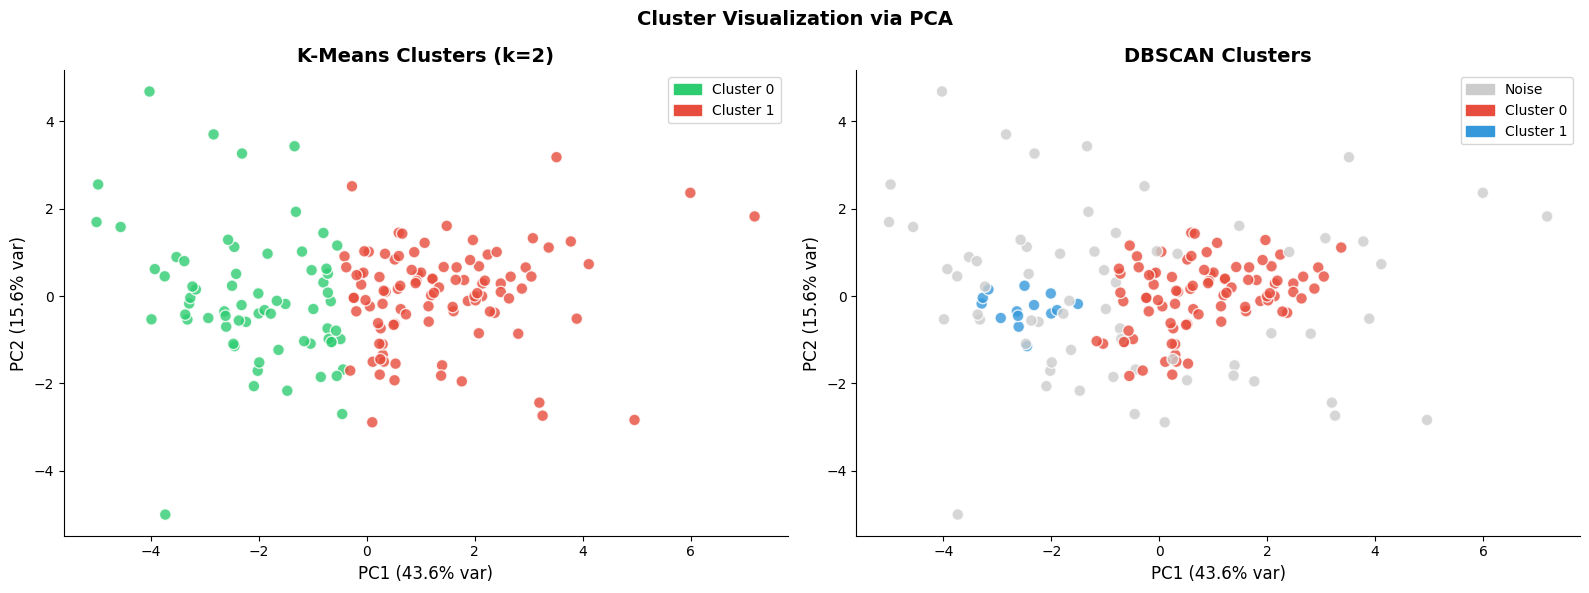

In [ ]:
# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means PCA plot
km_colors = [PALETTE[c % len(PALETTE)] for c in df['kmeans_cluster']]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_colors, alpha=0.8, s=70, edgecolor='white')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1%} var)')
axes[0].set_title(f'K-Means Clusters (k={optimal_k})', fontweight='bold')
patches = [mpatches.Patch(color=PALETTE[i % len(PALETTE)], label=f'Cluster {i}') for i in range(optimal_k)]
axes[0].legend(handles=patches, loc='upper right')

# DBSCAN PCA plot
dbscan_unique = sorted(df['dbscan_cluster'].unique())
db_cmap = {c: PALETTE[i % len(PALETTE)] if c != -1 else '#cccccc' for i, c in enumerate(dbscan_unique)}
db_colors = [db_cmap[c] for c in df['dbscan_cluster']]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=db_colors, alpha=0.8, s=70, edgecolor='white')
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1%} var)')
axes[1].set_title('DBSCAN Clusters', fontweight='bold')
patches_db = [mpatches.Patch(color=db_cmap[c], label='Noise' if c == -1 else f'Cluster {c}') for c in dbscan_unique]
axes[1].legend(handles=patches_db, loc='upper right')

plt.suptitle('Cluster Visualization via PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Cluster Profiling & Business Insights

In [ ]:
profile_cols = ['child_mort', 'income', 'life_expec', 'gdpp', 'health', 'total_fer']
cluster_profile = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
print("=== K-Means Cluster Profiles ===")
print(cluster_profile.to_string())


=== K-Means Cluster Profiles ===
                child_mort    income  life_expec      gdpp  health  total_fer
kmeans_cluster                                                               
0                    76.49   4142.13       61.82   1944.54    6.14       4.44
1                    12.66  25856.40       76.41  20347.30    7.27       1.95


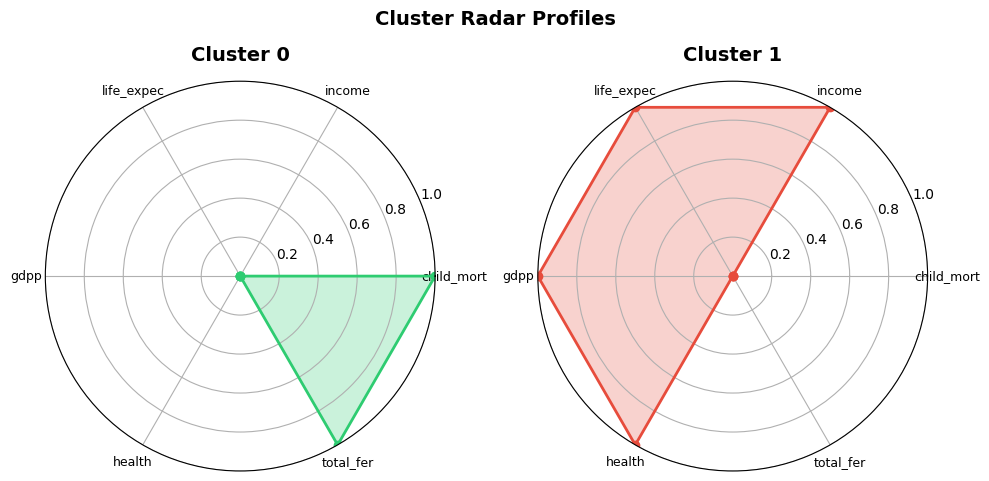

In [ ]:
# Radar / Spider chart for cluster profiles
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, optimal_k, figsize=(5*optimal_k, 5), subplot_kw=dict(polar=True))
if optimal_k == 1: axes = [axes]

norm_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min() + 1e-9)
angles = np.linspace(0, 2*np.pi, len(profile_cols), endpoint=False).tolist()
angles += angles[:1]

for idx, ax in enumerate(axes):
    vals = norm_profile.iloc[idx].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=PALETTE[idx % len(PALETTE)])
    ax.fill(angles, vals, alpha=0.25, color=PALETTE[idx % len(PALETTE)])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(profile_cols, size=9)
    ax.set_title(f'Cluster {idx}', pad=15, fontweight='bold')
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Radar Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_profiles.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Top countries per cluster
print("=== Top Countries per K-Means Cluster ===\n")
for c in sorted(df['kmeans_cluster'].unique()):
    subset = df[df['kmeans_cluster'] == c].sort_values('gdpp', ascending=False)
    print(f"Cluster {c} (n={len(subset)}) — top by GDP:")
    print("  " + ", ".join(subset['country'].head(8).tolist()))
    print(f"  Avg GDP: ${subset['gdpp'].mean():,.0f}  |  Avg Life Exp: {subset['life_expec'].mean():.1f}  |  Avg Child Mort: {subset['child_mort'].mean():.1f}")
    print()


=== Top Countries per K-Means Cluster ===

Cluster 0 (n=67) — top by GDP:
  Equatorial Guinea, Gabon, South Africa, Botswana, Namibia, Iraq, Timor-Leste, Tonga
  Avg GDP: $1,945  |  Avg Life Exp: 61.8  |  Avg Child Mort: 76.5

Cluster 1 (n=100) — top by GDP:
  Luxembourg, Norway, Switzerland, Qatar, Denmark, Sweden, Australia, Netherlands
  Avg GDP: $20,347  |  Avg Life Exp: 76.4  |  Avg Child Mort: 12.7



## 10. Final Summary & Actionable Insights

In [ ]:
print("=" * 60)
print("  CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY")
print("=" * 60)

print("\n📊 CLASSIFICATION RESULTS:")
best_model_name = max(results, key=lambda m: results[m]['acc'])
for name, r in results.items():
    marker = " ← BEST" if name == best_model_name else ""
    print(f"  {name:25s} | Test Acc: {r['acc']:.4f} | CV Acc: {r['cv']:.4f}{marker}")

print("\n🔵 CLUSTERING RESULTS:")
print(f"  K-Means (k={optimal_k}):")
print(f"    Silhouette Score    : {sil_km:.4f}")
print(f"    Davies-Bouldin      : {db_km:.4f}")
print(f"    Calinski-Harabasz   : {ch_km:.2f}")
print(f"\n  DBSCAN (eps={best_eps}, min_samples={best_min}):")
print(f"    Clusters found      : {n_db_clusters}")
print(f"    Noise points        : {n_noise}")

print("\n💡 KEY INSIGHTS:")
print("  • GDP per capita & income are the strongest predictors of development class")
print("  • Child mortality & life expectancy are highly inversely correlated")
print("  • K-Means reveals clear geographic-economic groupings")
print("  • DBSCAN identifies outlier economies that defy typical patterns")
print("  • Ensemble models (RF, XGBoost) significantly outperform baseline classifiers")
print("\n✅ Pipeline complete!")


  CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY

📊 CLASSIFICATION RESULTS:
  Logistic Regression       | Test Acc: 0.9706 | CV Acc: 0.9405 ← BEST
  Decision Tree             | Test Acc: 0.9706 | CV Acc: 0.8422
  Random Forest             | Test Acc: 0.9706 | CV Acc: 0.9028
  XGBoost                   | Test Acc: 0.9706 | CV Acc: 0.9328
  Voting Ensemble           | Test Acc: 0.9706 | CV Acc: 0.9179

🔵 CLUSTERING RESULTS:
  K-Means (k=2):
    Silhouette Score    : 0.2748
    Davies-Bouldin      : 1.3799
    Calinski-Harabasz   : 65.08

  DBSCAN (eps=1.5, min_samples=10):
    Clusters found      : 2
    Noise points        : 64

💡 KEY INSIGHTS:
  • GDP per capita & income are the strongest predictors of development class
  • Child mortality & life expectancy are highly inversely correlated
  • K-Means reveals clear geographic-economic groupings
  • DBSCAN identifies outlier economies that defy typical patterns
  • Ensemble models (RF, XGBoost) significantly outperform baseline classifiers